In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

In [3]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import RandomizedSearchCV, train_test_split

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [4]:
MODEL_READY_CSV = Path("../data/model_ready/match_by_match.csv")

In [5]:
dataset = pd.read_csv(MODEL_READY_CSV)

In [6]:
dataset.shape

(1243, 31)

In [7]:
dataset.head()

,match_id,date,venue,team1,team2,toss_winner,toss_decision,winner,result,team1_score,team2_score,team1_players,team2_players,team1_total_wins_against_team2,team2_total_wins_against_team1,team1_wins_against_team2_last_three,team2_wins_against_team1_last_three,team1_form_last_5,team2_form_last_5,team1_last_5_avg_score,team1_last_5_runs_conceded,team2_last_5_avg_score,team2_last_5_runs_conceded,team1_chasing_win_rate,team1_defending_win_rate,team2_chasing_win_rate,team2_defending_win_rate,venue_avg_score,chasing_win_rate_venue,team1_win_rate_at_venue,team2_win_rate_at_venue
0,335982,2008-04-18,"M Chinnaswamy Stadium, Bengaluru",Kolkata Knight Riders,Royal Challengers Bengaluru,Royal Challengers Bengaluru,field,Kolkata Knight Riders,won by 140 runs,222,82,"R Dravid, W Jaffer, V Kohli, JH Kallis, CL Whi...","SC Ganguly, BB McCullum, RT Ponting, DJ Hussey...",0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,335983,2008-04-19,"Punjab Cricket Association IS Bindra Stadium, ...",Chennai Super Kings,Punjab Kings,Chennai Super Kings,bat,Chennai Super Kings,won by 33 runs,240,207,"K Goel, JR Hopes, KC Sangakkara, Yuvraj Singh,...","PA Patel, ML Hayden, MEK Hussey, MS Dhoni, SK ...",0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,335984,2008-04-19,"Arun Jaitley Stadium, Delhi",Rajasthan Royals,Delhi Capitals,Rajasthan Royals,bat,Delhi Capitals,won by 9 wickets,129,132,"G Gambhir, V Sehwag, S Dhawan, MK Tiwary, KD K...","T Kohli, YK Pathan, SR Watson, M Kaif, DS Lehm...",0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,335986,2008-04-20,"Eden Gardens, Kolkata",Deccan Chargers,Kolkata Knight Riders,Deccan Chargers,bat,Kolkata Knight Riders,won by 5 wickets,110,112,"WP Saha, BB McCullum, RT Ponting, SC Ganguly, ...","AC Gilchrist, Y Venugopal Rao, VVS Laxman, A S...",0,0,0,0,0,1,0.0,0.0,222.0,82.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,335985,2008-04-20,"Wankhede Stadium, Mumbai",Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,bat,Royal Challengers Bengaluru,won by 5 wickets,165,166,"L Ronchi, ST Jayasuriya, DJ Thornely, RV Uthap...","S Chanderpaul, R Dravid, LRPL Taylor, JH Kalli...",0,0,0,0,0,0,0.0,0.0,82.0,222.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
dataset.tail(5)

,match_id,date,venue,team1,team2,toss_winner,toss_decision,winner,result,team1_score,team2_score,team1_players,team2_players,team1_total_wins_against_team2,team2_total_wins_against_team1,team1_wins_against_team2_last_three,team2_wins_against_team1_last_three,team1_form_last_5,team2_form_last_5,team1_last_5_avg_score,team1_last_5_runs_conceded,team2_last_5_avg_score,team2_last_5_runs_conceded,team1_chasing_win_rate,team1_defending_win_rate,team2_chasing_win_rate,team2_defending_win_rate,venue_avg_score,chasing_win_rate_venue,team1_win_rate_at_venue,team2_win_rate_at_venue
1238,1529313,2026-05-24,"Eden Gardens, Kolkata",Delhi Capitals,Kolkata Knight Riders,Kolkata Knight Riders,field,Delhi Capitals,won by 40 runs,203,163,"Kuldeep Yadav, Abishek Porel, KL Rahul, SU Par...","SP Narine, AM Rahane, FH Allen, MK Pandey, C G...",14,20,0,3,3,4,187.2,186.8,180.6,173.2,0.490,0.409,0.565,0.500,160.73,0.563,0.200,0.564
1239,1535462,2026-05-26,"Himachal Pradesh Cricket Association Stadium, ...",Royal Challengers Bengaluru,Gujarat Titans,Gujarat Titans,field,Royal Challengers Bengaluru,won by 92 runs,254,162,"R Shepherd, VR Iyer, V Kohli, D Padikkal, RM P...","K Khejroliya, B Sai Sudharsan, Shubman Gill, J...",4,4,1,2,3,4,197.2,204.2,202.2,157.6,0.550,0.486,0.690,0.500,172.81,0.438,0.667,0.000
1240,1535463,2026-05-27,Maharaja Yadavindra Singh International Cricke...,Rajasthan Royals,Sunrisers Hyderabad,Sunrisers Hyderabad,field,Rajasthan Royals,won by 47 runs,243,196,"YBK Jaiswal, V Suryavanshi, Dhruv Jurel, R Par...","PP Hinge, Abhishek Sharma, TM Head, Ishan Kish...",9,14,0,3,2,3,200.0,209.4,184.4,183.8,0.545,0.383,0.492,0.359,210.90,0.750,1.000,0.000
1241,1535464,2026-05-29,Maharaja Yadavindra Singh International Cricke...,Rajasthan Royals,Gujarat Titans,Rajasthan Royals,bat,Gujarat Titans,won by 7 wickets,214,219,"TU Deshpande, YBK Jaiswal, V Suryavanshi, Dhru...","Mohammed Siraj, B Sai Sudharsan, Shubman Gill,...",3,7,2,1,3,3,203.6,203.4,201.2,175.8,0.545,0.383,0.667,0.500,212.33,0.600,1.000,0.000
1242,1535465,2026-05-31,"Narendra Modi Stadium, Ahmedabad",Gujarat Titans,Royal Challengers Bengaluru,Royal Challengers Bengaluru,field,Royal Challengers Bengaluru,won by 5 wickets,155,161,"M Prasidh Krishna, B Sai Sudharsan, Shubman Gi...","JA Duffy, VR Iyer, V Kohli, D Padikkal, RM Pat...",4,5,1,2,3,4,199.2,188.2,207.4,194.8,0.667,0.500,0.550,0.486,176.40,0.469,0.600,0.429


In [9]:
dataset["winner"].value_counts()

winner
Mumbai Indians                 155
Chennai Super Kings            148
Royal Challengers Bengaluru    143
Kolkata Knight Riders          140
Punjab Kings                   126
Delhi Capitals                 125
Rajasthan Royals               123
Sunrisers Hyderabad            102
Gujarat Titans                  47
Lucknow Super Giants            34
Deccan Chargers                 29
Rising Pune Supergiants         15
Gujarat Lions                   13
Pune Warriors                   12
Kochi Tuskers Kerala             6
Name: count, dtype: int64

In [10]:
dataset.isna().sum()

match_id                                0
date                                    0
venue                                   0
team1                                   0
team2                                   6
toss_winner                             0
toss_decision                           0
winner                                 25
result                                 25
team1_score                             0
team2_score                             0
team1_players                           0
team2_players                           0
team1_total_wins_against_team2          0
team2_total_wins_against_team1          0
team1_wins_against_team2_last_three     0
team2_wins_against_team1_last_three     0
team1_form_last_5                       0
team2_form_last_5                       0
team1_last_5_avg_score                  0
team1_last_5_runs_conceded              0
team2_last_5_avg_score                  0
team2_last_5_runs_conceded              0
team1_chasing_win_rate            

In [9]:
dataset = dataset.dropna(subset=['winner'])

dataset.shape

(1218, 31)

In [10]:
def get_winner_slot(row):
    if row['winner'] == row['team1']:
        return 1
    else:
        return 0

In [11]:
def get_toss_winner_slot(row):
    if row['toss_winner'] == row['team1']:
        return 1
    else:
        return 0

In [12]:
dataset['winner_slot'] = dataset.apply(get_winner_slot, axis=1)
dataset['toss_winner_slot'] = dataset.apply(get_toss_winner_slot, axis=1)

dataset.head(5)

,match_id,date,venue,team1,team2,toss_winner,toss_decision,winner,result,team1_score,...,team1_chasing_win_rate,team1_defending_win_rate,team2_chasing_win_rate,team2_defending_win_rate,venue_avg_score,chasing_win_rate_venue,team1_win_rate_at_venue,team2_win_rate_at_venue,winner_slot,toss_winner_slot
0,335982,2008-04-18,"M Chinnaswamy Stadium, Bengaluru",Kolkata Knight Riders,Royal Challengers Bengaluru,Royal Challengers Bengaluru,field,Kolkata Knight Riders,won by 140 runs,222,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
1,335983,2008-04-19,"Punjab Cricket Association IS Bindra Stadium, ...",Chennai Super Kings,Punjab Kings,Chennai Super Kings,bat,Chennai Super Kings,won by 33 runs,240,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1
2,335984,2008-04-19,"Arun Jaitley Stadium, Delhi",Rajasthan Royals,Delhi Capitals,Rajasthan Royals,bat,Delhi Capitals,won by 9 wickets,129,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1
3,335986,2008-04-20,"Eden Gardens, Kolkata",Deccan Chargers,Kolkata Knight Riders,Deccan Chargers,bat,Kolkata Knight Riders,won by 5 wickets,110,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1
4,335985,2008-04-20,"Wankhede Stadium, Mumbai",Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,bat,Royal Challengers Bengaluru,won by 5 wickets,165,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1


In [ ]:
# I have removed the non-numerical data and toss-winner and winner 
# because i already have winner and toss-winner in winner_slot and toss_slot which are in 0 or 1 unlike RCB, CSK, SRH, 
# also team1 score and team2 score because if i have them, then there is not point in using machine learning to predict result

dataset = dataset.drop(["date", "venue", "result", "toss_winner",
                        "toss_decision", "team1", "team2",
                        "team1_score", 
                        "team2_score", 
                        "team1_players", 
                        "team2_players", "winner"], axis=1)

dataset = dataset.set_index("match_id")

dataset.head(5)

,team1_score,team1_total_wins_against_team2,team2_total_wins_against_team1,team1_wins_against_team2_last_three,team2_wins_against_team1_last_three,team1_form_last_5,team2_form_last_5,team1_last_5_avg_score,team1_last_5_runs_conceded,team2_last_5_avg_score,...,team1_chasing_win_rate,team1_defending_win_rate,team2_chasing_win_rate,team2_defending_win_rate,venue_avg_score,chasing_win_rate_venue,team1_win_rate_at_venue,team2_win_rate_at_venue,winner_slot,toss_winner_slot
match_id,,,,,,,,,,,,,,,,,,,,,
335982,222,0,0,0,0,0,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
335983,240,0,0,0,0,0,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1
335984,129,0,0,0,0,0,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1
335986,110,0,0,0,0,0,1,0.0,0.0,222.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1
335985,165,0,0,0,0,0,0,0.0,0.0,82.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1


In [ ]:
# dataset.to_csv("ipl_final_training_with_team1_score.csv")

In [15]:
# from sklearn.preprocessing import StandardScaler

# standard_dataset_array = StandardScaler().fit_transform(dataset.iloc[:, 1:])
# standard_dataset = pd.DataFrame(standard_dataset_array, columns = dataset.columns[1:])
# print(standard_dataset)

# # I have removed the non-numerical data and toss-winner and winner 
# # because i already have winner and toss-winner in winner_slot and toss_slot which are in 0 or 1 unlike RCB, CSK, SRH, 
# # also team1 score and team2 score because if i have them, then there is not point in using machine learning to predict result

# standard_dataset = standard_dataset.drop(["date", "venue", "result", "toss_winner",
#                         "toss_decision", "team1", "team2",
#                         "team1_score", 
#                         "team2_score", 
#                         "team1_players", 
#                         "team2_players", "winner"], axis=1)

# standard_dataset = standard_dataset.set_index("match_id")

# print(dataset.head(5))

In [17]:
cols = list(dataset.columns)
cols.remove("winner_slot")
cols = ["winner_slot"] + cols
dataset = dataset[cols]

In [18]:
print(dataset.head(5))

          winner_slot  team1_score  team1_total_wins_against_team2  \
match_id                                                             
335982              1          222                               0   
335983              1          240                               0   
335984              0          129                               0   
335986              0          110                               0   
335985              0          165                               0   

          team2_total_wins_against_team1  team1_wins_against_team2_last_three  \
match_id                                                                        
335982                                 0                                    0   
335983                                 0                                    0   
335984                                 0                                    0   
335986                                 0                                    0   
335985                 

In [19]:
target_value = [0]
print(dataset.columns[target_value])

Index(['winner_slot'], dtype='str')


In [20]:
input_values = range(1, dataset.columns.shape[0])

print(dataset.columns[input_values])

Index(['team1_score', 'team1_total_wins_against_team2',
       'team2_total_wins_against_team1', 'team1_wins_against_team2_last_three',
       'team2_wins_against_team1_last_three', 'team1_form_last_5',
       'team2_form_last_5', 'team1_last_5_avg_score',
       'team1_last_5_runs_conceded', 'team2_last_5_avg_score',
       'team2_last_5_runs_conceded', 'team1_chasing_win_rate',
       'team1_defending_win_rate', 'team2_chasing_win_rate',
       'team2_defending_win_rate', 'venue_avg_score', 'chasing_win_rate_venue',
       'team1_win_rate_at_venue', 'team2_win_rate_at_venue',
       'toss_winner_slot'],
      dtype='str')


In [21]:
from sklearn.preprocessing import StandardScaler

# Assume dataset has target in column 0, and features from column 1 onward
X = dataset.iloc[:, 1:]  # input features
y = dataset.iloc[:, 0]   # target

# Standardize only the features
X_scaled = StandardScaler().fit_transform(X)

# Optional: convert back to DataFrame if needed
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print(dataset.iloc[:, input_values])


          team1_score  team1_total_wins_against_team2  \
match_id                                                
335982            222                               0   
335983            240                               0   
335984            129                               0   
335986            110                               0   
335985            165                               0   
...               ...                             ...   
1529313           203                              14   
1535462           254                               4   
1535463           243                               9   
1535464           214                               3   
1535465           155                               4   

          team2_total_wins_against_team1  team1_wins_against_team2_last_three  \
match_id                                                                        
335982                                 0                                    0   
335983         

In [22]:
print(X_scaled_df)

      team1_score  team1_total_wins_against_team2  \
0        1.574590                       -1.164224   
1        2.109099                       -1.164224   
2       -1.187043                       -1.164224   
3       -1.751248                       -1.164224   
4       -0.118024                       -1.164224   
...           ...                             ...   
1213     1.010385                        1.455856   
1214     2.524829                       -0.415630   
1215     2.198184                        0.520113   
1216     1.337030                       -0.602778   
1217    -0.414974                       -0.415630   

      team2_total_wins_against_team1  team1_wins_against_team2_last_three  \
0                          -1.149157                            -1.418187   
1                          -1.149157                            -1.418187   
2                          -1.149157                            -1.418187   
3                          -1.149157                   

In [23]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

x = dataset.iloc[:, input_values]
y = dataset.iloc[:, target_value]

X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model.fit(X_train, Y_train)
predictions = model.predict(X_test)

accuracy = accuracy_score(Y_test, predictions)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", classification_report(Y_test, predictions))
print("Confusion Matrix:\n", confusion_matrix(Y_test, predictions))


Accuracy: 0.5738
Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.62      0.62       135
           1       0.52      0.51      0.52       109

    accuracy                           0.57       244
   macro avg       0.57      0.57      0.57       244
weighted avg       0.57      0.57      0.57       244

Confusion Matrix:
 [[84 51]
 [53 56]]


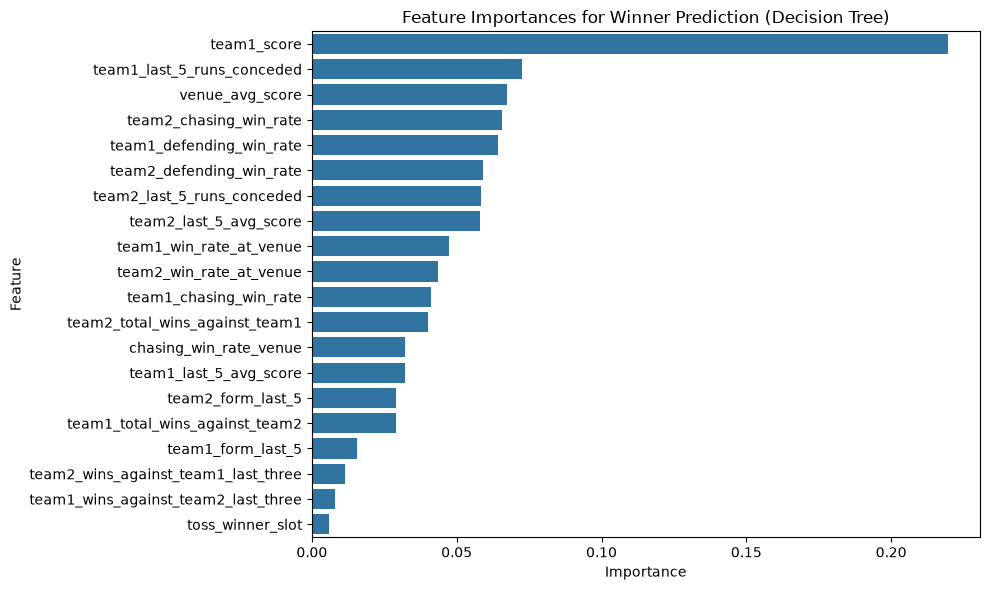

In [25]:
model = RandomForestClassifier()

x = dataset.iloc[:, input_values]
y = dataset.iloc[:, target_value]

X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size = 0.2 , random_state = 50)

model.fit(X_train, Y_train)
predictions = model.predict(X_test)

# Evaluate
accuracy = accuracy_score(Y_test, predictions)

print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", classification_report(Y_test, predictions))
print("Confusion Matrix:\n", confusion_matrix(Y_test, predictions))

c:\venvs\datasci\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Accuracy: 0.6189
Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.67      0.66       132
           1       0.59      0.55      0.57       112

    accuracy                           0.62       244
   macro avg       0.62      0.61      0.61       244
weighted avg       0.62      0.62      0.62       244

Confusion Matrix:
 [[89 43]
 [50 62]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Input and Target
x = dataset.iloc[:, input_values]  # feature columns
y = dataset.iloc[:, target_value]  # target column

# Standardize input features (optional for RandomForest, but good for consistency)
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=50)

# Define parameter grid
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

rf = RandomForestClassifier(random_state=50)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=50
)

random_search.fit(X_train, Y_train)

best_model = random_search.best_estimator_

predictions = best_model.predict(X_test)

accuracy = accuracy_score(Y_test, predictions)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", classification_report(Y_test, predictions))
print("Confusion Matrix:\n", confusion_matrix(Y_test, predictions))


Fitting 5 folds for each of 50 candidates, totalling 250 fits


c:\venvs\datasci\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Accuracy: 0.6066
Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.66      0.64       132
           1       0.58      0.54      0.56       112

    accuracy                           0.61       244
   macro avg       0.60      0.60      0.60       244
weighted avg       0.61      0.61      0.61       244

Confusion Matrix:
 [[87 45]
 [51 61]]


In [27]:
from sklearn.model_selection import GridSearchCV

# Define a smaller parameter grid for exhaustive search
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, Y_train)

best_model = grid_search.best_estimator_
predictions = best_model.predict(X_test)

print(f"Accuracy: {accuracy_score(Y_test, predictions):.4f}")
print("Classification Report:\n", classification_report(Y_test, predictions))
print("Confusion Matrix:\n", confusion_matrix(Y_test, predictions))


Fitting 5 folds for each of 48 candidates, totalling 240 fits


c:\venvs\datasci\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Accuracy: 0.6189
Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.66      0.65       132
           1       0.59      0.57      0.58       112

    accuracy                           0.62       244
   macro avg       0.62      0.62      0.62       244
weighted avg       0.62      0.62      0.62       244

Confusion Matrix:
 [[87 45]
 [48 64]]


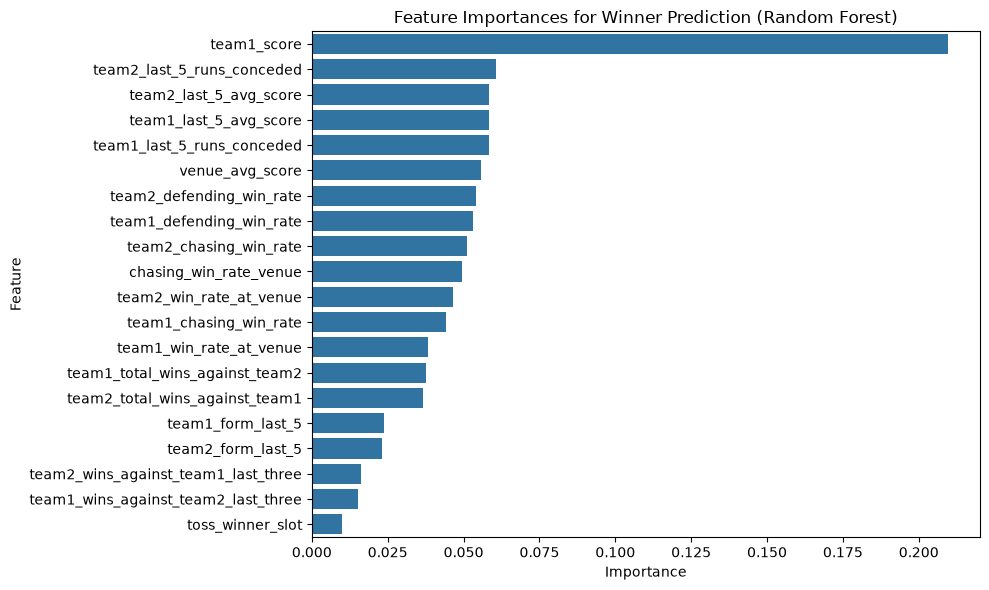

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns



In [29]:
# print(standard_dataset.columns)

In [30]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

model = SVC(kernel='rbf')

# x = dataset.iloc[:, input_values]
x = X_scaled_df
y = dataset.iloc[:, target_value]

X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=50)

model.fit(X_train, Y_train)
predictions = model.predict(X_test)

accuracy = accuracy_score(Y_test, predictions)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", classification_report(Y_test, predictions))
print("Confusion Matrix:\n", confusion_matrix(Y_test, predictions))


Accuracy: 0.6311
Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.71      0.68       132
           1       0.61      0.54      0.57       112

    accuracy                           0.63       244
   macro avg       0.63      0.62      0.62       244
weighted avg       0.63      0.63      0.63       244

Confusion Matrix:
 [[94 38]
 [52 60]]


c:\venvs\datasci\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [31]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns

# importance = model.coef_[0]  # For binary classification
# features = x.columns

# # Sort by absolute importance
# sorted_indices = np.argsort(np.abs(importance))[::-1]
# sorted_importance = np.abs(importance)[sorted_indices]
# sorted_features = features[sorted_indices]

# plt.figure(figsize=(10, 6))
# sns.barplot(x=sorted_importance, y=sorted_features)
# plt.title("Feature Importance (Coefficient Magnitude)")
# plt.xlabel("Importance")
# plt.ylabel("Feature")
# plt.tight_layout()
# plt.show()


In [ ]:


model = LogisticRegression(max_iter=1000)

# x = dataset.iloc[:,input_values]
x = X_scaled_df
y = dataset.iloc[:, target_value]

X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=50)

model.fit(X_train, Y_train)
predictions = model.predict(X_test)

accuracy = accuracy_score(Y_test, predictions)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", classification_report(Y_test, predictions))
print("Confusion Matrix:\n", confusion_matrix(Y_test, predictions))


Accuracy: 0.6434
Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.72      0.69       132
           1       0.63      0.55      0.59       112

    accuracy                           0.64       244
   macro avg       0.64      0.64      0.64       244
weighted avg       0.64      0.64      0.64       244

Confusion Matrix:
 [[95 37]
 [50 62]]


c:\venvs\datasci\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


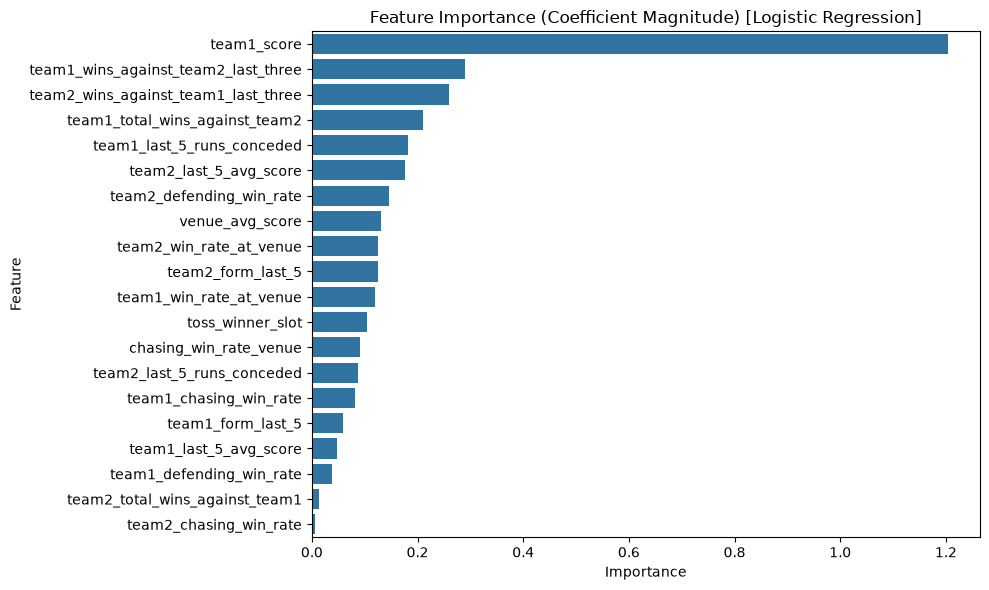

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

importance = model.coef_[0]  # For binary classification
features = x.columns

# Sort by absolute importance
sorted_indices = np.argsort(np.abs(importance))[::-1]
sorted_importance = np.abs(importance)[sorted_indices]
sorted_features = features[sorted_indices]

plt.figure(figsize=(10, 6))
sns.barplot(x=sorted_importance, y=sorted_features)
plt.title("Feature Importance (Coefficient Magnitude) [Logistic Regression]")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [34]:
from sklearn.linear_model import LinearRegression
import numpy as np

model = LinearRegression()

# x = dataset.iloc[:, input_values]
x = X_scaled_df
y = dataset.iloc[:, target_value]

X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=50)

model.fit(X_train, Y_train)
preds_continuous = model.predict(X_test)

# Convert continuous output to class labels (binary classification assumed)
predictions = np.round(preds_continuous).astype(int)

accuracy = accuracy_score(Y_test, predictions)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", classification_report(Y_test, predictions))
print("Confusion Matrix:\n", confusion_matrix(Y_test, predictions))


Accuracy: 0.6475
Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.72      0.69       132
           1       0.63      0.56      0.59       112

    accuracy                           0.65       244
   macro avg       0.64      0.64      0.64       244
weighted avg       0.65      0.65      0.65       244

Confusion Matrix:
 [[95 37]
 [49 63]]


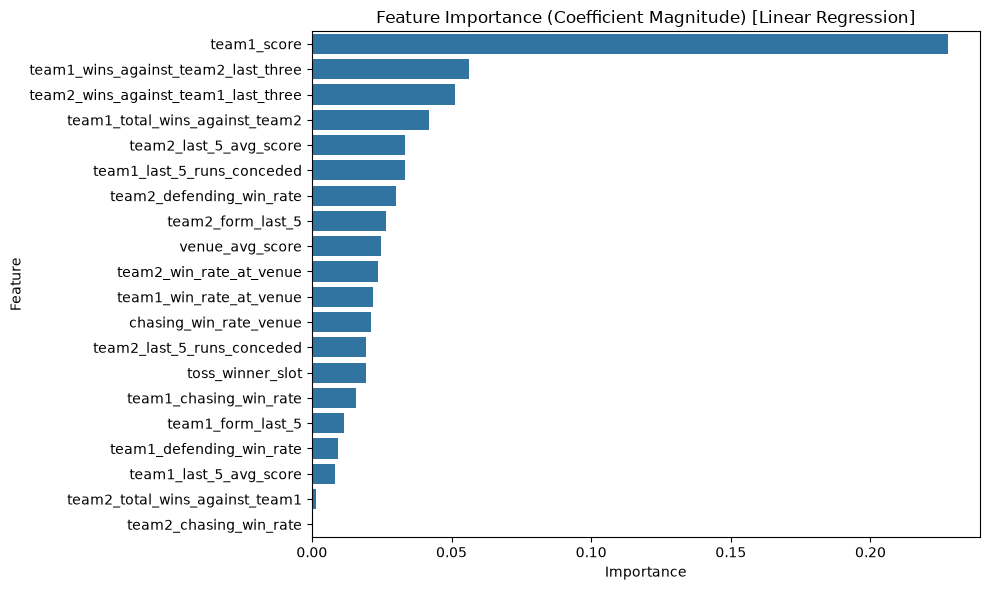

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

importance = model.coef_[0]  # For binary classification
features = x.columns

# Sort by absolute importance
sorted_indices = np.argsort(np.abs(importance))[::-1]
sorted_importance = np.abs(importance)[sorted_indices]
sorted_features = features[sorted_indices]

plt.figure(figsize=(10, 6))
sns.barplot(x=sorted_importance, y=sorted_features)
plt.title("Feature Importance (Coefficient Magnitude) [Linear Regression]")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [36]:
print(dataset.columns[input_values])

# Confirm class balance
print(y.value_counts(normalize=True))
print(y.shape)

Index(['team1_score', 'team1_total_wins_against_team2',
       'team2_total_wins_against_team1', 'team1_wins_against_team2_last_three',
       'team2_wins_against_team1_last_three', 'team1_form_last_5',
       'team2_form_last_5', 'team1_last_5_avg_score',
       'team1_last_5_runs_conceded', 'team2_last_5_avg_score',
       'team2_last_5_runs_conceded', 'team1_chasing_win_rate',
       'team1_defending_win_rate', 'team2_chasing_win_rate',
       'team2_defending_win_rate', 'venue_avg_score', 'chasing_win_rate_venue',
       'team1_win_rate_at_venue', 'team2_win_rate_at_venue',
       'toss_winner_slot'],
      dtype='str')
winner_slot
0              0.546798
1              0.453202
Name: proportion, dtype: float64
(1218, 1)


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Use your existing dataset and input/target values
x = dataset.iloc[:, input_values]
y = dataset.iloc[:, target_value]

# Flatten y if it's a DataFrame
y = y.values.ravel()

# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=70)

# Create and train the model
model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
model.fit(X_train, Y_train)

# Predict and evaluate
predictions = model.predict(X_test)
accuracy = accuracy_score(Y_test, predictions)

print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", classification_report(Y_test, predictions))
print("Confusion Matrix:\n", confusion_matrix(Y_test, predictions))


c:\venvs\datasci\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:56:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.6516
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.66      0.67       131
           1       0.62      0.64      0.63       113

    accuracy                           0.65       244
   macro avg       0.65      0.65      0.65       244
weighted avg       0.65      0.65      0.65       244

Confusion Matrix:
 [[87 44]
 [41 72]]


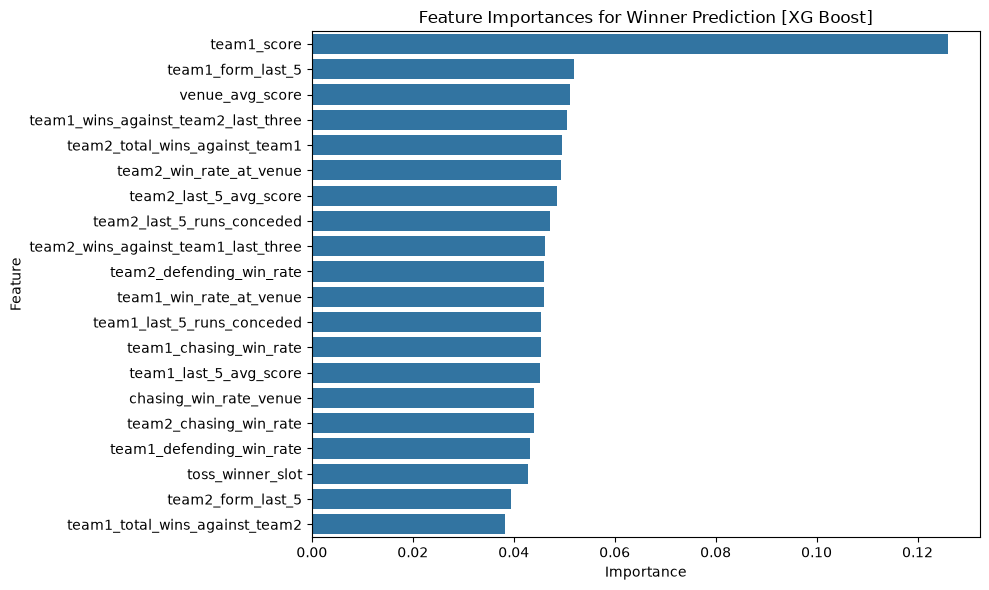

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = model.feature_importances_
features = x.columns

# Sort by importance
sorted_indices = importances.argsort()[::-1]
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[sorted_indices], y=features[sorted_indices])
plt.title("Feature Importances for Winner Prediction [XG Boost]")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()